In [10]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator


# ---------- style (same as earlier plot) ----------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage[utf8]{inputenc}
        \usepackage{xcolor}
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath}
        \sansmath
    """,
})

def hex2rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))

line_colors_hex = ["#1f77b4", "#d78e20", "#c459a1", "#498c41"]
line_colors = [hex2rgb(h) for h in line_colors_hex]

font_scale = 1.5
label_fs = int(12 * font_scale)
legend_fs = int(9 * font_scale)
tick_labelsize = int(10 * font_scale)
scaled_markersize = int(round(4 * font_scale))

PT_PER_INCH = 72
FIGSIZE = (300 / PT_PER_INCH, 200 / PT_PER_INCH)

In [11]:
def extract_n_from_name(name):
    m = re.search(r"_n(\d+)", name)
    return int(m.group(1)) if m else None


def extract_trials_from_name(name):
    m = re.search(r"_trials(\d+)", name)
    return int(m.group(1)) if m else None


def extract_epsilon_max_from_name(name):
    m = re.search(r"_epsilon_max([0-9p]+)", name)
    if not m:
        return None
    return float(m.group(1).replace("p", "."))

In [12]:
base = os.getcwd()  # or set explicitly to your data folder
pattern = os.path.join(base, "fidelity_vs_epsilon*.csv")
files = sorted(glob.glob(pattern))

# apply your filters
files = [
    f for f in files
    if (
        ("_steps10" in os.path.basename(f)) and
        ("_k2" in os.path.basename(f)) and
        ("_epsilon_max0p001" in os.path.basename(f))
    )
]

print(f"[+] Found {len(files)} matching CSVs")

rows = []

for f in files:
    try:
        df = pd.read_csv(f)
    except Exception:
        continue

    if "epsilon" not in df.columns or "fidelity" not in df.columns:
        continue

    basename = os.path.basename(f)
    n = extract_n_from_name(basename)
    R = extract_trials_from_name(basename)
    eps_max = extract_epsilon_max_from_name(basename)

    if n is None or R is None:
        continue

    cutoff = eps_max if eps_max is not None else 0.01
    df = df[df["epsilon"] <= cutoff]

    for _, row in df.iterrows():
        rows.append({
            "n": int(n),
            "R": int(R),
            "epsilon": float(row["epsilon"]),
            "fidelity": float(row["fidelity"]),
        })

all_df = pd.DataFrame(rows)

# maximize over R per (n, epsilon)
all_df = all_df.sort_values(
    ["n", "epsilon", "fidelity", "R"],
    ascending=[True, True, False, True],
)

best = all_df.groupby(["n", "epsilon"], as_index=False).first()

[+] Found 11 matching CSVs


[+] Saved to fidelity_vs_epsilon_overlay_maxR_with_Rmarkers_0p001.svg


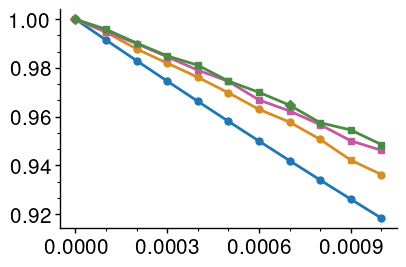

In [20]:
# map R to markers
unique_R = sorted(best["R"].unique())
marker_cycle = ["o", "s", "D", "^", "v", "<", ">", "P", "X", "*", "h", "H", "p", "d"]
r_to_marker = {r: marker_cycle[i % len(marker_cycle)] for i, r in enumerate(unique_R)}

unique_n = sorted(best["n"].unique())
n_to_color = {nval: line_colors[i % len(line_colors)] for i, nval in enumerate(unique_n)}

fig, ax = plt.subplots(figsize=FIGSIZE)

for nval in unique_n:
    sub = best[best["n"] == nval].sort_values("epsilon")

    label = "Unamplified" if nval == 1 else f"n={nval}"
    color = n_to_color[nval]

    ax.plot(
        sub["epsilon"],
        sub["fidelity"],
        linestyle="-",
        linewidth=2,
        color=color,
        label=label,
    )

    for r in unique_R:
        sub_r = sub[sub["R"] == r]
        if sub_r.empty:
            continue

        ax.plot(
            sub_r["epsilon"],
            sub_r["fidelity"],
            linestyle="None",
            marker=r_to_marker[r],
            markersize=int(0.85 * scaled_markersize),
            color=color,
        )

# Hide axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")

from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.xaxis.set_minor_locator(AutoMinorLocator(3))
ax.yaxis.set_minor_locator(AutoMinorLocator(3))

ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)

ax.grid(False)

# Legend 1: n (colors)
# leg1 = ax.legend(loc="upper right", fontsize=legend_fs, frameon=False)
# ax.add_artist(leg1)

# Legend 2: argmax R (markers)
marker_handles = [
    plt.Line2D(
        [0], [0],
        marker=r_to_marker[r],
        linestyle="None",
        color="black",
        markersize=int(scaled_markersize),
        label=rf"$r_\mathrm{{max}}={r}$",
    )
    for r in unique_R
]

# ax.legend(
#     handles=marker_handles,
#     loc="upper left",
#     bbox_to_anchor=(0.4, 1.0),
#     fontsize=legend_fs,
#     frameon=False,
# )

fig.tight_layout()

out_path = "fidelity_vs_epsilon_overlay_maxR_with_Rmarkers_0p001.svg"

fig.tight_layout()
fig.savefig(out_path, format="svg")
print(f"[+] Saved to {out_path}")

plt.show()


[+] Saved to fidelity_vs_epsilon_overlay_allR_shaded.pdf


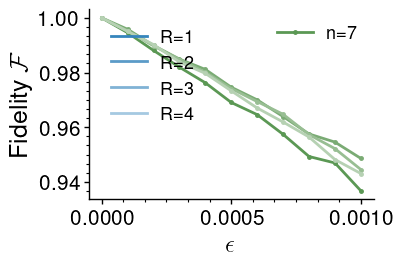

In [19]:
# Cell: overlay ALL R (no maximization). Same n color, shade by R (higher R -> lighter)
# Assumes you already have: all_df with columns ["n","R","epsilon","fidelity"], plus:
# FIGSIZE, line_colors, label_fs, legend_fs, tick_labelsize, scaled_markersize

import numpy as np
import matplotlib.colors as mcolors

def _blend_with_white(color, t):
    """
    t in [0,1]. t=0 -> original color, t=1 -> white.
    """
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple((1 - t) * rgb + t * np.ones(3))

# build consistent mappings
unique_n = sorted(all_df["n"].unique())
n_to_color = {nval: line_colors[i % len(line_colors)] for i, nval in enumerate(unique_n)}

unique_R = sorted(all_df["R"].unique())

# shade schedule: higher R -> lighter, but keep decent contrast
# t=0.10 (almost original) up to t=0.60 (noticeably lighter, not washed out)
if len(unique_R) > 1:
    t_vals = np.linspace(0.10, 0.60, len(unique_R))
else:
    t_vals = np.array([0.10])

r_to_t = {r: t_vals[i] for i, r in enumerate(unique_R)}

fig, ax = plt.subplots(figsize=FIGSIZE)

for nval in [7]:
    base_color = n_to_color[nval]
    for r in unique_R:
        sub = all_df[(all_df["n"] == nval) & (all_df["R"] == r)].sort_values("epsilon")
        if sub.empty:
            continue

        shade_color = _blend_with_white(base_color, r_to_t[r])

        # optional: only label one entry per n in the legend (so it doesn't explode)
        label = ("Unamplified" if nval == 1 else f"n={nval}") if r == unique_R[0] else None

        ax.plot(
            sub["epsilon"],
            sub["fidelity"],
            linestyle="-",
            linewidth=2,
            marker=".",
            markersize=int(0.85 * scaled_markersize),
            color=shade_color,
            label=label,
        )

ax.set_xlabel(r"$\epsilon$", fontsize=label_fs)
ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)

# spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")

ax.xaxis.set_minor_locator(AutoMinorLocator(6))
ax.yaxis.set_minor_locator(AutoMinorLocator(6))

ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)

ax.grid(False)

# Legend 1: n (colors)  (uses the base color; lines in plot are shaded variants)
leg1 = ax.legend(loc="upper right", fontsize=legend_fs, frameon=False)
ax.add_artist(leg1)

# Legend 2: R shade guide (show a little line sample per R)
shade_handles = [
    plt.Line2D(
        [0], [0],
        color=_blend_with_white((0, 0, 0), 1.0),  # placeholder, overwritten below
    )
]

shade_handles = [
    plt.Line2D(
        [0], [0],
        color=_blend_with_white((0, 0, 0), 0.0),  # placeholder
    )
    for _ in unique_R
]

# Use the first n's base color as the exemplar for the shade legend
exemplar_color = n_to_color[unique_n[0]]
shade_handles = [
    plt.Line2D(
        [0], [0],
        linestyle="-",
        linewidth=2,
        color=_blend_with_white(exemplar_color, r_to_t[r]),
        label=f"R={r}",
    )
    for r in unique_R
]

ax.legend(
    handles=shade_handles,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    fontsize=legend_fs,
    frameon=False,
)

fig.tight_layout()
out_path = "fidelity_vs_epsilon_overlay_allR_shaded.pdf"
fig.savefig(out_path)
print(f"[+] Saved to {out_path}")
plt.show()